# Multi-Configuration Comparison (Hyperparameter Tuning)

This notebook demonstrates how DSEngine's **Zero-Code** design handles experiment comparison.

Instead of writing loops in Python, you simply declare multiple distinct experiments (with different hyperparameter configurations) inside a single YAML file. The notebook then iterates over these experiments, runs them, and compares their results side-by-side.

---


## 1 — The Multi-Experiment YAML Config

Notice how `08_hyperparams.yml` defines three distinct experiments: `exp_A_baseline`, `exp_B_standard_iqr`, and `exp_C_robust_yj`.

In [1]:
with open('../configs/08_hyperparams.yml', 'r') as f:
    print(f.read())

# 08_Hyperparameter_Comparison_Demo

# This file contains 3 different configurations (experiments) to demonstrate
# how to easily test and compare different hyperparameters for the same dataset
# purely through declarative YAML.

# Experiment A - Baseline (No transformations)
exp_A_baseline:
  data:
    source: "examples/datasets/verify_prep.csv"
  output:
    path: "examples/outputs/08_Hyperparams_Declarative/"
    format: ["json"]
  steps:
    - name: "impute_mean"
      type: "impute"
      columns: ["age", "income"]
      params:
        method: "mean"
    - name: "relationships_baseline"
      type: "relationships"
      params:
        alpha: 0.05

# Experiment B - Standard Scaling & IQR Clipping
exp_B_standard_iqr:
  data:
    source: "examples/datasets/verify_prep.csv"
  output:
    path: "examples/outputs/08_Hyperparams_Declarative/"
    format: ["json"]
  steps:
    - name: "impute_median"
      type: "impute"
      columns: ["age", "income"]
      params:
        method: "me

## 2 — Run All Configurations Iteratively

We loop through the experiment names and run the engine for each. The results are isolated safely in their respective output directories.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from ds_engine.utils import pipeline_runner

config_path = '../configs/08_hyperparams.yml'
experiments = ['exp_A_baseline', 'exp_B_standard_iqr', 'exp_C_robust_yj']

for exp in experiments:
    print(f"\n{'='*60}")
    print(f"Executing: {exp}")
    print(f"{'='*60}")
    pipeline_runner.run(config_path, exp, display_plots=False)

Dataset has fewer than 30 rows. This may affect the reliability of statistical tests.



Executing: exp_A_baseline
+--------------------------------------------------------------+
|  DSEngine  |  Experiment: exp_A_baseline                |
|  Config  : ../configs/08_hyperparams.yml                   |
|  Started : 2026-03-25 11:51:04                             |
+--------------------------------------------------------------+
> Loading data...
  Source  : D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\datasets\verify_prep.csv
  Shape   : 15 rows x 4 columns
  Columns : age, income, group, score
> Pre-flight inspection...
  v  No fatal issues.
  !  1 warning(s) — check before interpreting results:
     [1] Dataset has fewer than 30 rows. This may affect the reliability of statistical tests.
> Running steps (2 total):
  [1/2] impute_mean      (impute        ) ... done  (0.00s)
  [2/2] relationships_baseline (relationships ) ... done  (0.16s)
> Saving outputs...


Dataset has fewer than 30 rows. This may affect the reliability of statistical tests.


  Plots : 3 figure(s) -> D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\outputs\08_Hyperparams_Declarative\exp_A_baseline\20260325_115104\plots/
  JSON  : D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\outputs\08_Hyperparams_Declarative\exp_A_baseline\20260325_115104\report.json
+--------------------------------------------------------------+
|  v  Run complete                                             |
|  Steps  : 2 completed, 0 failed                             |
|  Time   : 0.55s total                                        |
|  Output : outputs\08_Hyperparams_Declarative\exp_A_baseline\20260325_115104 |
+--------------------------------------------------------------+

Executing: exp_B_standard_iqr
+--------------------------------------------------------------+
|  DSEngine  |  Experiment: exp_B_standard_iqr            |
|  Config  : ../configs/08_hyperparams.yml                   |
|  Starte

Dataset has fewer than 30 rows. This may affect the reliability of statistical tests.


  Plots : 3 figure(s) -> D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\outputs\08_Hyperparams_Declarative\exp_B_standard_iqr\20260325_115104\plots/
  JSON  : D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\outputs\08_Hyperparams_Declarative\exp_B_standard_iqr\20260325_115104\report.json
+--------------------------------------------------------------+
|  v  Run complete                                             |
|  Steps  : 4 completed, 0 failed                             |
|  Time   : 0.49s total                                        |
|  Output : outputs\08_Hyperparams_Declarative\exp_B_standard_iqr\20260325_115104 |
+--------------------------------------------------------------+

Executing: exp_C_robust_yj
+--------------------------------------------------------------+
|  DSEngine  |  Experiment: exp_C_robust_yj               |
|  Config  : ../configs/08_hyperparams.yml                   |


## 3 — Compare the Results (e.g. Correlation Strengths)

Now we parse the generated JSON logs to compare the effect of the different preprocessing configurations. For this demo, we'll see how the different data preparation techniques affected the **Pearson Correlation** coefficient between `age` and `score`.

,Experiment,Age-Score_Correlation,Correlations_Found
0,exp_A_baseline,0.3589,3
1,exp_B_standard_iqr,0.3603,3
2,exp_C_robust_yj,0.4032,3


C:\Users\STEPLESMOSENSESARL\AppData\Local\Temp\ipykernel_33068\1479290722.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comp, x='Experiment', y='Age-Score_Correlation', palette='viridis')


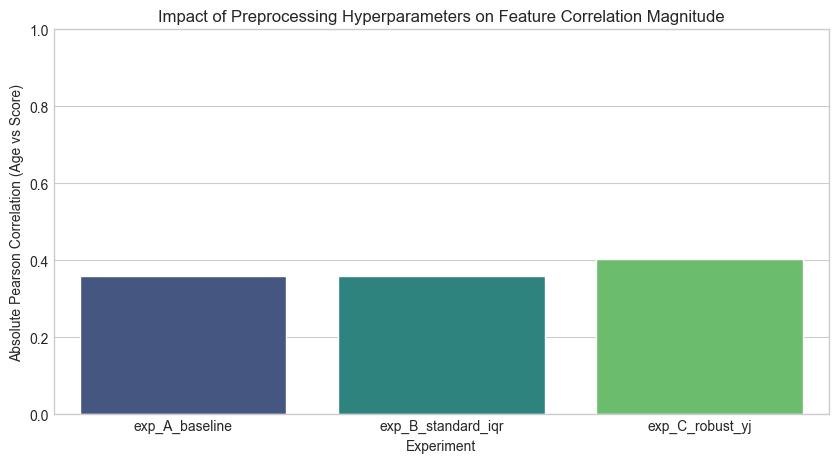

In [3]:
import glob, json
import pandas as pd

comparison_results = []

for exp in experiments:
    # Find the latest JSON report for this experiment
    reports = sorted(
        glob.glob(f'../examples/outputs/08_Hyperparams_Declarative/{exp}/*/report.json'),
        reverse=True
    )
    
    if not reports:
        continue
        
    latest = reports[0]
    with open(latest, 'r') as f:
        report = json.load(f)
        
    # Find the relationships block
    # The name of the step in YAML changes by exp, so we search for age vs score
    rel_block = None
    age_score_corr = None
    total_pairs = 0
    
    for step_name, data in report['steps'].items():
        if 'age_vs_score' in data:
            age_score_corr = data['age_vs_score']['value']
            total_pairs = len([k for k in data.keys() if '_vs_' in k])
            break
        elif 'score_vs_age' in data:
            age_score_corr = data['score_vs_age']['value']
            total_pairs = len([k for k in data.keys() if '_vs_' in k])
            break
            
    if age_score_corr is not None:
        comparison_results.append({
            'Experiment': exp,
            'Age-Score_Correlation': round(abs(age_score_corr), 4),
            'Correlations_Found': total_pairs
        })

import matplotlib.pyplot as plt
import seaborn as sns

df_comp = pd.DataFrame(comparison_results)
display(df_comp)

# Visualise the impact of preprocessing on correlation
plt.figure(figsize=(10, 5))
sns.barplot(data=df_comp, x='Experiment', y='Age-Score_Correlation', palette='viridis')
plt.title('Impact of Preprocessing Hyperparameters on Feature Correlation Magnitude')
plt.ylabel('Absolute Pearson Correlation (Age vs Score)')
plt.ylim(0, 1.0)
plt.show()

## Conclusion

As shown above, the DSEngine architecture treats **Data Preparation as Hyperparameters**. 

You don't need to re-write scripts to test if Robust Scaling works better than Standard Scaling, or if Yeo-Johnson transforms unveil deeper correlations. You simply create a new block in the YAML file and run it.